<a href="https://colab.research.google.com/github/himabindusgs-svg/LinearRegression/blob/main/DecisionTree_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Income  Credit Score Loan Status
0      20           580    Rejected
1      25           600    Rejected
2      30           650    Approved
3      35           670    Approved
4      40           700    Approved
5      45           720    Approved
6      50           750    Approved
7      55           780    Approved


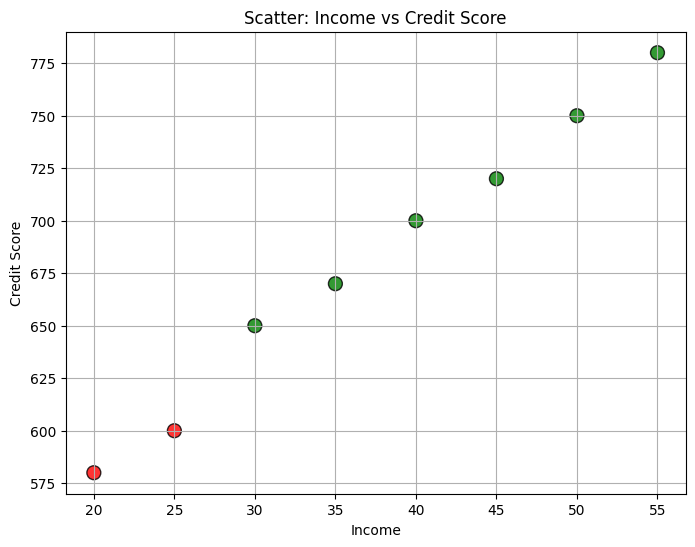


Target Loan Status Prediction: Approved

Accuracy Score: 1.0

Confusion Matrix:
 [[6 0]
 [0 2]]


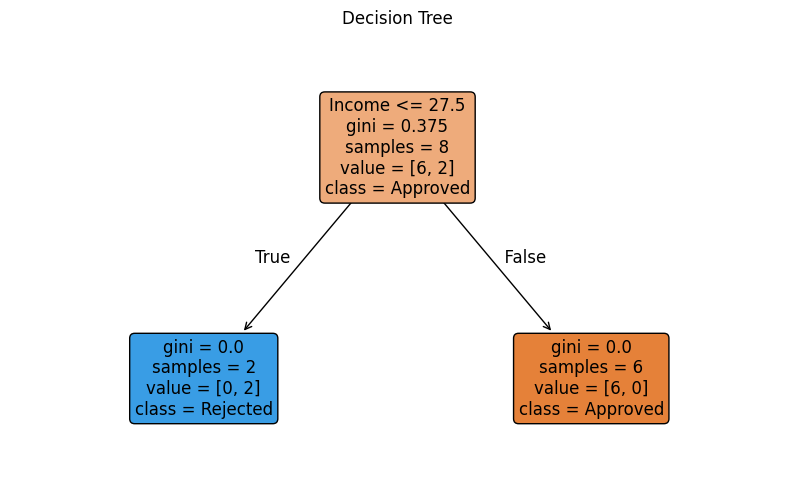

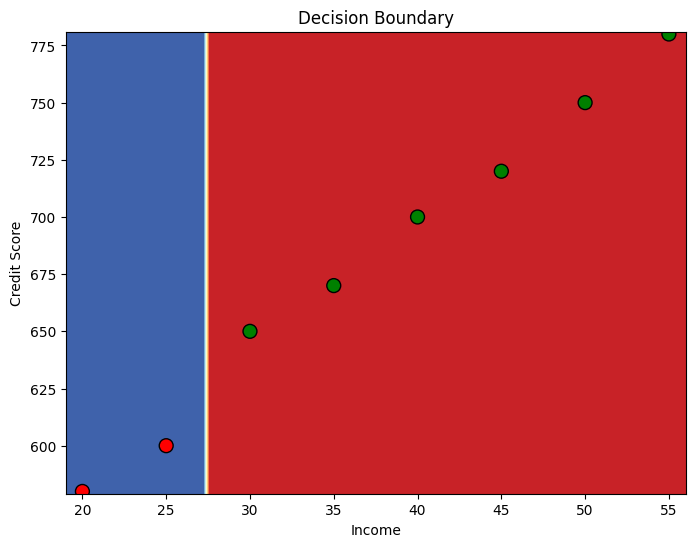

In [7]:
# Scenario: Predicting Loan Approval Based on Applicant Profile
# 🎯 Context
# A bank wants to predict whether a loan application will be Approved or Rejected
# based on two key factors: Applicant Income (₹ in thousands) and Credit Score.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, confusion_matrix

# STEP 2 — Load dataset
df = {
    'Income': [20, 25, 30, 35, 40, 45, 50, 55],
    'Credit Score': [580, 600, 650, 670, 700, 720, 750, 780],
    'Loan Status': ['Rejected', 'Rejected', 'Approved', 'Approved',
                    'Approved','Approved', 'Approved', 'Approved']
}
data = pd.DataFrame(df)
print(data)

# STEP 4 — Scatter plot with color mapping
plt.figure(figsize=(8, 6))

# Use Loan Status for coloring
color_map = {'Approved': 'green', 'Rejected': 'red'}
colors = data['Loan Status'].map(color_map)

plt.scatter(
    data['Income'],
    data['Credit Score'],
    c=colors,
    s=100,
    alpha=0.8,
    edgecolor='black'
)

plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.title('Scatter: Income vs Credit Score')
plt.grid(True)
plt.show()

# STEP 5 — Features and target
X = data[['Income', 'Credit Score']]
y = data['Loan Status']

# STEP 6 — Train Decision Tree Model
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

# STEP 7 — Prediction (fixed feature names warning)
test_point = pd.DataFrame([[32, 640]], columns=['Income','Credit Score'])
prediction = clf.predict(test_point)
print("\nTarget Loan Status Prediction:", prediction[0])

# STEP 8 — Evaluation
y_pred = clf.predict(X)
print("\nAccuracy Score:", accuracy_score(y, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y, y_pred))

# STEP 9 — Visualize Decision Tree
plt.figure(figsize=(10, 6))
plot_tree(
    clf,
    feature_names=['Income', 'Credit Score'],
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree")
plt.show()

# STEP 10 — Plot Decision Boundary
fig, ax = plt.subplots(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    cmap=plt.cm.RdYlBu,
    response_method="predict",
    ax=ax,
    xlabel="Income",
    ylabel="Credit Score"
)

# Overlay original data points
plt.scatter(
    data['Income'],
    data['Credit Score'],
    c=colors,
    edgecolor='black',
    s=100
)
plt.title("Decision Boundary")
plt.show()